# Faster Monthly GFS T2M with Dask + grib2io

This notebook focuses on **speeding up compute steps** (mean/std/time series) using Dask while keeping the same grib2io xarray backend workflow.

Key ideas used here:
- Keep remote open/index lightweight with grib2io filters + .idx
- Use chunked Dask arrays for reductions
- Persist reused arrays once, then run multiple analyses
- Optionally run a local Dask distributed scheduler for better task throughput

## 1. Imports and Dask setup

If `distributed` is installed, this starts a local cluster; otherwise it falls back to the default scheduler.

In [1]:
import time
import warnings

from dask import config as dask_config
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")

# Optional distributed scheduler
USE_DISTRIBUTED = True
if USE_DISTRIBUTED:
    try:
        from dask.distributed import Client, LocalCluster

        cluster = LocalCluster(n_workers=4, threads_per_worker=1, processes=True, dashboard_address=":8787")
        client = Client(cluster)
        print(client)
    except Exception as exc:
        print(f"distributed not available, using default scheduler: {type(exc).__name__}: {exc}")
        client = None
else:
    client = None

# Small scheduler tuning for reduction-heavy graphs
dask_config.set({"array.slicing.split_large_chunks": False})

<Client: 'tcp://127.0.0.1:50441' processes=4 threads=4, memory=32.00 GiB>


## 2. Configuration

Adjust year/month and chunking to trade off memory vs throughput.

Tip: start with one month, validate behavior, then scale to full year.

In [16]:
BUCKET = "noaa-gfs-bdp-pds"
YEAR = "2025"
MONTH = "01"
GRID = "0p25"
CYCLE = "00"
FORECAST = "f000"

USE_ICECHUNK = True

# Benchmark knobs
BENCH_VALID_TIME = 4
BENCH_STRIDE = 4
BENCH_FILE_COUNT = 365
RUN_BLOCK_BASELINE = True

storage_options = {
    "anon": True,
    "config_kwargs": {
        "connect_timeout": 30,
        "read_timeout": 120,
        "retries": {"max_attempts": 10, "mode": "adaptive"},
    },
}

T2M_FILTERS = {"shortName": "TMP", "typeOfFirstFixedSurface": 103}

# Use a full year of daily files.
start = pd.to_datetime(f"{YEAR}-01-01")
end = pd.to_datetime(f"{YEAR}-12-31")
dates = pd.date_range(start, end, freq="D")

urls = [
    f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/gfs.t{CYCLE}z.pgrb2.{GRID}.{FORECAST}"
    for d in dates
]

print(f"Period: {start.date()} to {end.date()} ({len(urls)} files)")
print("First:", urls[0])
print("Last:", urls[-1])
print(
    f"Benchmark knobs -> valid_time={BENCH_VALID_TIME}, stride={BENCH_STRIDE}, "
    f"file_count={BENCH_FILE_COUNT}"
)

Period: 2025-01-01 to 2025-12-31 (365 files)
First: s3://noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000
Last: s3://noaa-gfs-bdp-pds/gfs.20251231/00/atmos/gfs.t00z.pgrb2.0p25.f000
Benchmark knobs -> valid_time=4, stride=4, file_count=365


## 3. Open multi-file dataset lazily

Use grib2io-specific kwargs directly in `xr.open_mfdataset(...)`.

`chunks={}` keeps lazy chunked arrays from backend metadata.

In [3]:
t0 = time.perf_counter()
ds = xr.open_mfdataset(
    urls,
    engine="grib2io",
    use_icechunk=USE_ICECHUNK,
    storage_options=storage_options,
    filters=T2M_FILTERS,
    max_workers=4,
    network_timeout=300,
    max_concurrent_requests=2,
    chunks={},
)

print(f"Open/scanning done in {time.perf_counter() - t0:.2f}s")
print(ds)

  2026-06-04T15:48:45.334732Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-04T15:48:45.379110Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-04T15:48:45.603119Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-04T15:48:45.640123Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/proc

## 4. Build analysis array and apply Dask chunking

For repeated time reductions, rechunking mostly on `valid_time` can reduce scheduler overhead.

If memory is tight, lower `TIME_CHUNK`.

In [4]:
T2M_VAR = "TMP"

t2m = ds[T2M_VAR]
if "height_above_ground" in t2m.dims:
    t2m = t2m.isel(height_above_ground=0)

# K -> degC
t2m = t2m - 273.15
t2m.attrs["units"] = "degC"

TIME_CHUNK = 8
t2m = t2m.chunk({"valid_time": TIME_CHUNK})

print(t2m)
print("Chunking:", t2m.chunksizes)

<xarray.DataArray 'TMP' (valid_time: 31, y: 721, x: 1440)> Size: 129MB
dask.array<rechunk-merge, shape=(31, 721, 1440), dtype=float32, chunksize=(8, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 248B 2025-01-01 ... 2025...
    latitude             (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    longitude            (y, x) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    height_above_ground  float64 8B 2.0
Dimensions without coordinates: y, x
Attributes:
    _ARRAY_DIMENSIONS:         ['valid_time', 'height_above_ground', 'y', 'x']
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   103
    valueOfFirstFixedSurface:  2.0
    valid_time:                2025-01-01T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:                     degC
Chunking: Frozen({'valid_tim

## 5. Persist once, then run multiple products

If you compute mean, std, and time series from the same array, persisting can save repeated remote reads.

In [5]:
t0 = time.perf_counter()
t2m_persisted = t2m.persist()
_ = t2m_persisted.data
print(f"Persist submitted in {time.perf_counter() - t0:.2f}s")

Persist submitted in 0.01s


## 6. Timed reductions (mean and std)

These are the same products as your original workflow but leaning on Dask chunked reductions.

In [6]:
t0 = time.perf_counter()
t2m_mean = t2m_persisted.mean("valid_time").compute()
t_mean = time.perf_counter() - t0

t1 = time.perf_counter()
t2m_std = t2m_persisted.std("valid_time").compute()
t_std = time.perf_counter() - t1

print(f"mean compute: {t_mean:.2f}s")
print(f"std  compute: {t_std:.2f}s")

mean compute: 4.43s
std  compute: 0.28s


## 7. Benchmark: two Dask fetch modes

With this backend, fetched subsets are Dask-backed in both open patterns.
This section compares:
- `dask_light_fetch`: per-file `open_dataset` path (lighter graph)
- `dask_chunked_fetch`: `open_mfdataset(..., chunks={})` path

The cell prints whether each path is Dask-backed before execution and checks `max |diff|`.

In [22]:
from dask.base import is_dask_collection


def _select_t2m(da):
    out = da
    if "height_above_ground" in out.dims:
        out = out.isel(height_above_ground=0)
    out = out - 273.15
    out.attrs["units"] = "degC"
    return out


def _subset(da):
    v_n = min(int(BENCH_VALID_TIME), int(da.sizes.get("valid_time", 1)))
    return da.isel(
        valid_time=slice(0, v_n),
        y=slice(None, None, BENCH_STRIDE),
        x=slice(None, None, BENCH_STRIDE),
    )


bench_urls = urls[: max(1, int(BENCH_FILE_COUNT))]
print(f"Benchmark files: {len(bench_urls)}")


def fetch_subset_dask_light():
    parts = []
    for u in bench_urls:
        with xr.open_dataset(
            u,
            engine="grib2io",
            use_icechunk=USE_ICECHUNK,
            storage_options=storage_options,
            filters=T2M_FILTERS,
            network_timeout=300,
            max_concurrent_requests=2,
        ) as ds_local:
            arr = _subset(_select_t2m(ds_local[T2M_VAR]))
            print(f"light path dask-backed before execution: {is_dask_collection(arr.data)}")
            parts.append(arr.compute(scheduler="threads"))

    out = xr.concat(parts, dim="valid_time")
    v_n = min(int(BENCH_VALID_TIME), int(out.sizes.get("valid_time", 1)))
    return out.isel(valid_time=slice(0, v_n))


def fetch_subset_dask_chunked():
    with xr.open_mfdataset(
        bench_urls,
        engine="grib2io",
        use_icechunk=USE_ICECHUNK,
        storage_options=storage_options,
        filters=T2M_FILTERS,
        max_workers=4,
        network_timeout=300,
        max_concurrent_requests=2,
        chunks={},
    ) as ds_local:
        arr = _subset(_select_t2m(ds_local[T2M_VAR]))
        print(f"chunked path dask-backed before execution: {is_dask_collection(arr.data)}")
        return arr.compute(scheduler="threads")


t0 = time.perf_counter()
light_sub = fetch_subset_dask_light()
t_light = time.perf_counter() - t0

t1 = time.perf_counter()
chunked_sub = fetch_subset_dask_chunked()
t_chunked = time.perf_counter() - t1

bench_df = pd.DataFrame(
    [
        {"method": "dask_light_fetch", "seconds": t_light, "status": "ok"},
        {"method": "dask_chunked_fetch", "seconds": t_chunked, "status": "ok"},
    ]
).sort_values("seconds").reset_index(drop=True)
bench_df["speedup_vs_slowest"] = bench_df["seconds"].max() / bench_df["seconds"]
display(bench_df)

print(f"Subset shape: {tuple(chunked_sub.shape)}")
max_abs_diff = float(abs(light_sub - chunked_sub).max())
print(f"max |light - chunked|: {max_abs_diff:.6e} degC")

Benchmark files: 365
  2026-06-04T16:11:55.396485Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-04T16:11:55.436770Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

light path dask-backed before execution: True
  2026-06-04T16:11:56.098016Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-06-04T16:11:56.139074Z  WARN icechunk_arrow_object_store: The LocalFileSystem stora

,method,seconds,status,speedup_vs_slowest
0,dask_chunked_fetch,86.672694,ok,2.134572
1,dask_light_fetch,185.009093,ok,1.000000


Subset shape: (4, 181, 360)
max |light - chunked|: 0.000000e+00 degC


## 8. Quick plots

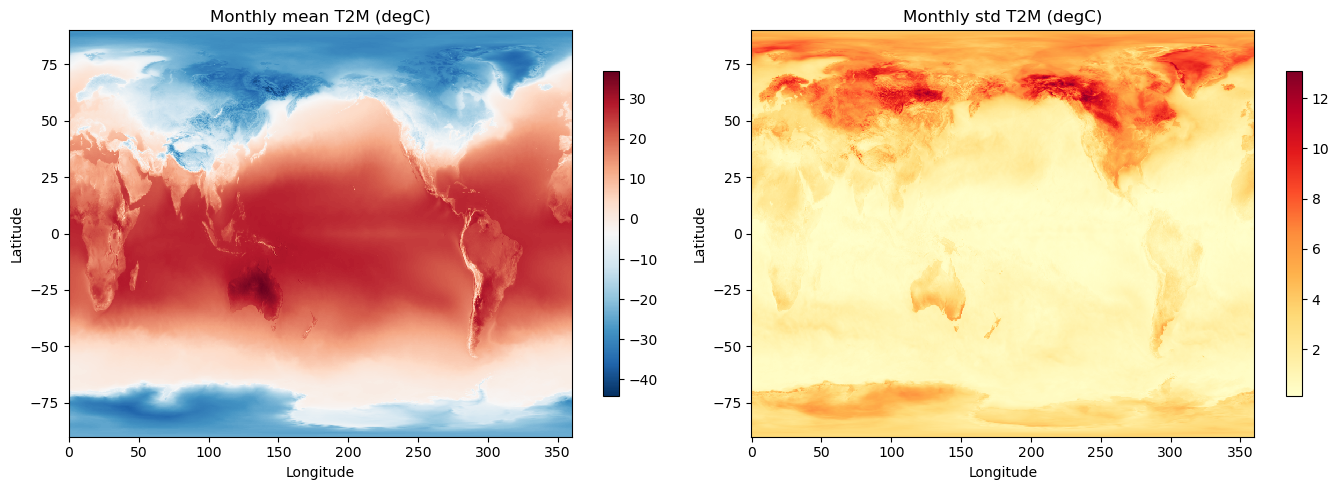

In [8]:
lats = t2m_mean.coords.get("latitude", t2m_mean.coords.get("y", None))
lons = t2m_mean.coords.get("longitude", t2m_mean.coords.get("x", None))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if lats is not None and lons is not None:
    pcm0 = axes[0].pcolormesh(lons, lats, t2m_mean.values, cmap="RdBu_r", shading="auto")
    pcm1 = axes[1].pcolormesh(lons, lats, t2m_std.values, cmap="YlOrRd", shading="auto")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
else:
    pcm0 = axes[0].imshow(t2m_mean.values, origin="upper", cmap="RdBu_r", aspect="auto")
    pcm1 = axes[1].imshow(t2m_std.values, origin="upper", cmap="YlOrRd", aspect="auto")

axes[0].set_title("Monthly mean T2M (degC)")
axes[1].set_title("Monthly std T2M (degC)")
plt.colorbar(pcm0, ax=axes[0], shrink=0.8)
plt.colorbar(pcm1, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Practical tuning checklist

- Increase `TIME_CHUNK` if workers are underutilized and memory is available
- Decrease `TIME_CHUNK` if you hit worker memory pressure
- Keep `max_concurrent_requests` modest (2-4) for stability on public S3
- Persist once if you compute multiple products from the same source array
- Scale from month to year only after timing and chunk sanity checks